#### Установка `scikit-learn`

In [ ]:
# !pip3 install scikit-learn

### Загрузка пакетов

In [2]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Загрузка датафрейма

In [3]:
churn_df = pd.read_csv('telecom_churn_clean.csv')
print(churn_df.columns)
print(churn_df.head())

Index(['Unnamed: 0', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge', 'customer_service_calls',
       'churn'],
      dtype='object')
   Unnamed: 0  account_length  ...  customer_service_calls  churn
0           0             128  ...                       1      0
1           1             107  ...                       1      0
2           2             137  ...                       0      0
3           3              84  ...                       2      0
4           4              75  ...                       3      0

[5 rows x 20 columns]


#### Разделим переменные на целевую и зависимые

In [5]:
y = churn_df['churn'].values
X = churn_df[['account_length', 'customer_service_calls']].values

In [6]:
print(y)
print(X)

[0 0 0 ... 0 0 0]
[[128   1]
 [107   1]
 [137   0]
 ...
 [ 28   2]
 [184   2]
 [ 74   0]]


#### Визуализация исзодных данных

In [7]:
X_1 = churn_df[['account_length', 'customer_service_calls']]
Y = churn_df['churn']

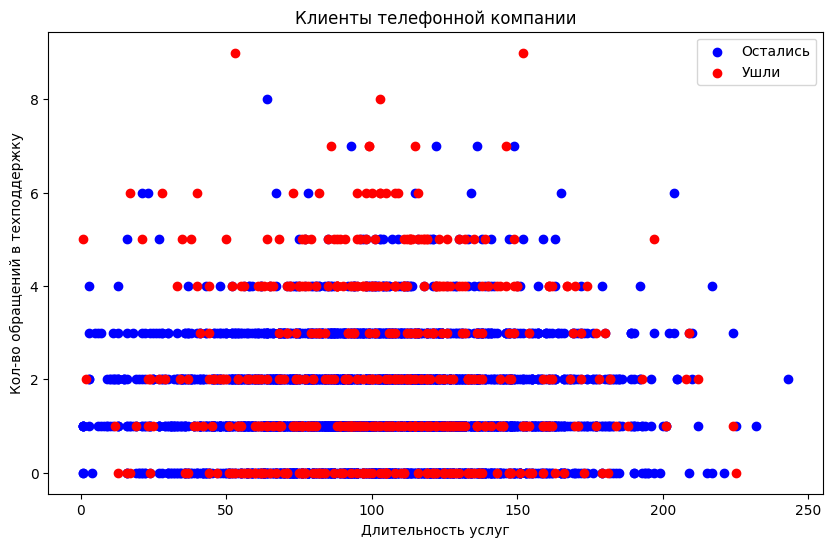

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(X_1[Y == 0]['account_length'], X_1[Y==0]['customer_service_calls'], color='blue', label='Остались')
plt.scatter(X_1[Y == 1]['account_length'], X_1[Y==1]['customer_service_calls'], color='red', label='Ушли')
plt.xlabel('Длительность услуг')
plt.ylabel('Кол-во обращений в техподдержку')
plt.title('Клиенты телефонной компании')
plt.legend()
plt.show()

#### Построение классификатора

In [9]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X, y)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Создание набора для предсказания

In [14]:
X_new = np.array([
    [20, 3],
    [90, 6],
    [115, 3],
    [110, 20],
    [300, 2]
])

In [15]:
y_pred = knn.predict(X_new)
print(y_pred)

[0 1 0 1 0]


#### Построение классификатора 2

In [24]:
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X, y)

,n_neighbors,25
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
y_pred = knn.predict(X_new)
print(y_pred)

[0 0 0 1 0]


In [27]:
print(churn_df['churn'].value_counts())

churn
0    2850
1     483
Name: count, dtype: int64


#### Разбиение данных

In [28]:
from sklearn.model_selection import train_test_split
X = churn_df.drop('churn', axis=1).values
y = churn_df['churn'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Обучение и предсказание

In [29]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
print(knn.score(X_test, y_test))

0.8590704647676162


#### Создание множества соседей

In [30]:
neighbors = np.arange(1, 31)
train_acc = {}
test_acc = {}

for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train)
    train_acc[neighbor] = knn.score(X_train, y_train)
    test_acc[neighbor] = knn.score(X_test, y_test)

print(neighbors)
print(train_acc)
print(test_acc)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
{1: 1.0, 2: 0.8885971492873218, 3: 0.8994748687171793, 4: 0.8750937734433608, 5: 0.878469617404351, 6: 0.8660915228807202, 7: 0.8705926481620405, 8: 0.8615903975993998, 9: 0.86384096024006, 10: 0.858589647411853, 11: 0.8604651162790697, 12: 0.8574643660915229, 13: 0.858589647411853, 14: 0.8567141785446362, 15: 0.858589647411853, 16: 0.8574643660915229, 17: 0.8582145536384096, 18: 0.8567141785446362, 19: 0.8570892723180795, 20: 0.8563390847711928, 21: 0.8567141785446362, 22: 0.8559639909977494, 23: 0.8563390847711928, 24: 0.8555888972243061, 25: 0.8559639909977494, 26: 0.8555888972243061, 27: 0.8555888972243061, 28: 0.8552138034508627, 29: 0.8552138034508627, 30: 0.8552138034508627}
{1: 0.7856071964017991, 2: 0.8470764617691154, 3: 0.8320839580209896, 4: 0.856071964017991, 5: 0.8545727136431784, 6: 0.8590704647676162, 7: 0.8605697151424287, 8: 0.8620689655172413, 9: 0.863568215892054, 10: 0.8605

#### Оценка модели от количества соседей

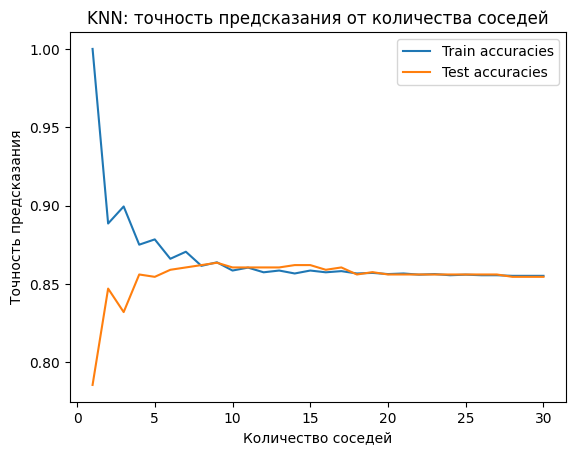

In [32]:
plt.title('KNN: точность предсказания от количества соседей')
plt.plot(neighbors, train_acc.values(), label = 'Train accuracies')
plt.plot(neighbors, test_acc.values(), label = 'Test accuracies')
plt.legend()
plt.xlabel('Количество соседей')
plt.ylabel('Точность предсказания')
plt.show()

In [33]:
print(2850 / (2850 + 483))

0.8550855085508551
